**Installing the required packages**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)  #here we are setting the option of pandas to display all the columns
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             recall_score, precision_score, f1_score)

**Reading the data**

In [154]:
df = pd.read_csv('/kaggle/input/datasets/asoktamang/pay-sim/pay_sim.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [155]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
print(df.head())
print('---')
print(df.shape)
print('---')
print(df.info())
print('---')

   step      type    amount     nameorig  oldbalanceorg  newbalanceorig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      namedest  oldbalancedest  newbalancedest  isfraud  isflaggedfraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
---
(6362620, 11)
---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Dat

**Features discription**

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER. (categorical feature)

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction.

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

In [156]:
df.describe()

,step,amount,oldbalanceorg,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


As we can see from the above table that features such as amount, oldbalanceorg, newbalanceorig, oldbalancedest, newbalancedest are right skewed as their mean value is greater than median value.

**Function to reduce the memory size of a dataset**

In [157]:
from pandas.api.types import is_numeric_dtype
def reduce_memory(df,verbose=True):
    start_memory = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype   #extracting the type of column
        if is_numeric_dtype(df[col]) :  #only if the current column type is number, we change the memory accordingly to the type whether its integer or float
            c_min,c_max = df[col].min(),df[col].max()
            if np.issubdtype(col_type,np.integer):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif np.issubdtype(col_type,np.floating):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
        else:  #if its a string then we change the type to category based on the number of unique values
           if (df[col].nunique() / len(df)) < 0.5:
                df[col] = df[col].astype('category')
    
    end_memory = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_memory:.2f} MB → {end_memory:.2f} MB '
              f'({100 * (start_memory - end_memory) / start_memory:.1f}% reduction)')
    
    return df
df = reduce_memory(df)

Memory usage: 533.97 MB → 309.78 MB (42.0% reduction)


**Data Preprocessing**

checking the null values in the dataset

In [158]:
df.isnull().sum()

step              0
type              0
amount            0
nameorig          0
oldbalanceorg     0
newbalanceorig    0
namedest          0
oldbalancedest    0
newbalancedest    0
isfraud           0
isflaggedfraud    0
dtype: int64

As we can see there are no null values in the dataset. Now we will check for duplicates.

In [159]:
df.duplicated().sum()

np.int64(0)

There is also not a single duplicated record in the dataset. So we can say that there is no missing value and no duplicated record in the dataset.

In [160]:
def classify(df):
    target = 'isfraud'
    numerical = [feature for feature in df.select_dtypes(include=np.number).columns if feature!=target]
    categorical = [feature for feature in df.select_dtypes(exclude=np.number).columns if feature!=target]
    return numerical, categorical
numerical, categorical = classify(df)
print(f'Numerical features: {numerical}')
print(f'Categorical features: {categorical}')

Numerical features: ['step', 'amount', 'oldbalanceorg', 'newbalanceorig', 'oldbalancedest', 'newbalancedest', 'isflaggedfraud']
Categorical features: ['type', 'nameorig', 'namedest']


**EDA**

Checking the distribution of the target variable

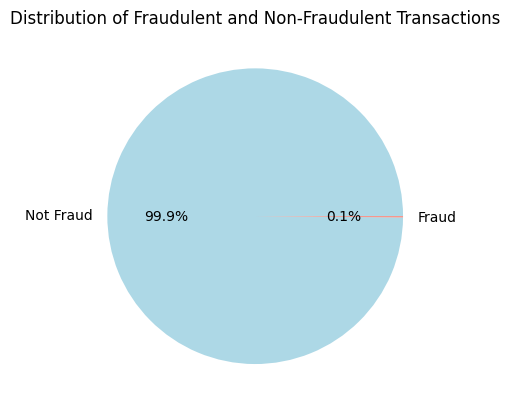

In [161]:
plt.pie(df['isfraud'].value_counts(),labels=['Not Fraud','Fraud'],autopct='%1.1f%%',colors=['lightblue','salmon'])
plt.title('Distribution of Fraudulent and Non-Fraudulent Transactions')
plt.show()

As we can observe that the dataset is highly imbalanced, with only 0.1% of positive class(fraud) and 99.9% of negative class(not fraud)

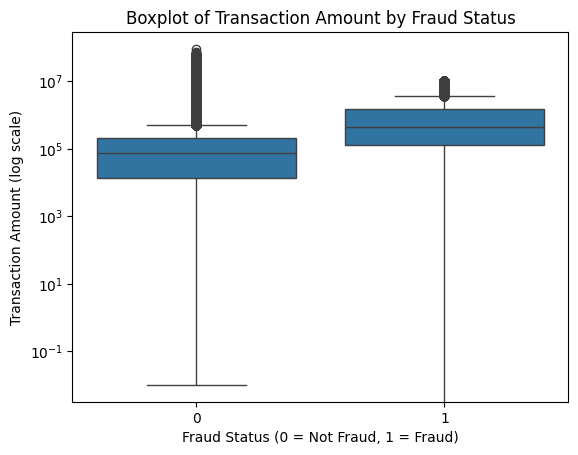

In [162]:
sns.boxplot(x='isfraud',y='amount',data=df)
plt.title('Boxplot of Transaction Amount by Fraud Status')
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Fraud Status (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Transaction Amount (log scale)')
plt.show()

Due to huge imbalance in dataset, the outliers in non fradulent transactions are dominating the plot as expected.

As we can observe from the above plot that, the difference in new and old balance is very high for fraudulent transaction compared to non_fraudulent transaction.

In [ ]:
df=df.sort_values('step').reset_index(drop=True)  #sorting the dataframe based on time step

In [163]:
df.columns

Index(['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud'],
      dtype='object')

In [164]:
df['day'] = np.ceil(df['step'] / 24).astype(int)  #converting the time step into days by dividing the step by 24 and taking the ceiling to get the day number
df['day_name'] = df['day'].map({1:'Monday',2:'Tuesday',3:'Wednesday',4:'Thursday',5:'Friday',6:'Saturday',7:'Sunday'})  #mapping the day number to the day name

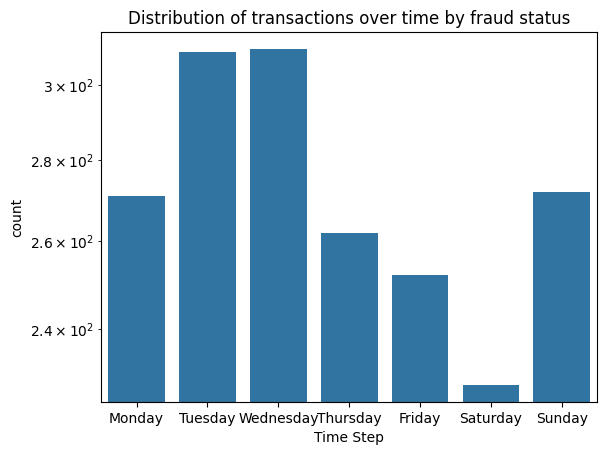

In [165]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='day_name',data=df[df['isfraud']==1],order=day_order)
plt.yscale('log')  # Log scale to better visualize the distribution
plt.title('Distribution of transactions over time by fraud status')
plt.xlabel('Time Step')
plt.show()

From the above plot, we can observe that there is a high fraudulent transaction on tuesday and wednesday where as the saturday had the least fraudulent transaction

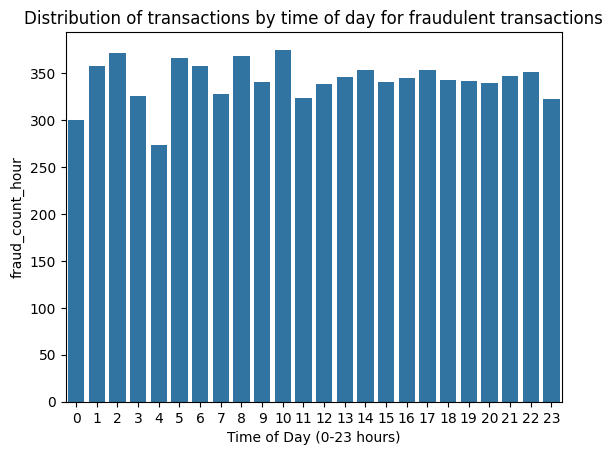

In [166]:
df['hour_of_day']=df['step']%24
fraud_by_hour = df[df['isfraud']==1].groupby('hour_of_day')['isfraud'].count().reset_index(name='fraud_count_hour')
sns.barplot(data=fraud_by_hour,x='hour_of_day',y='fraud_count_hour')
plt.title('Distribution of transactions by time of day for fraudulent transactions')
plt.xlabel('Time of Day (0-23 hours)')
plt.show()

"From the above analysis, we can see that most fraudulent transactions occur between 1 AM and 10 AM, with a peak between 5 AM and 8 AM. This could be attributed to two factors: first, account holders are less vigilant during early morning hours and may not notice suspicious activity immediately; second, banks typically have reduced real-time monitoring during off-peak hours, giving fraudsters a larger window of opportunity."

In [167]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,day,day_name,hour_of_day
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,1,Monday,1
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1,Monday,1
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,1,Monday,1
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,1,Monday,1
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,1,Monday,1


In [168]:
df['dest_type'] = np.where(df['namedest'].str.startswith('M'), 'Merchant', 'Customer')

In [169]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,day,day_name,hour_of_day,dest_type
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,1,Monday,1,Merchant
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1,Monday,1,Merchant
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,1,Monday,1,Customer
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,1,Monday,1,Customer
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,1,Monday,1,Merchant


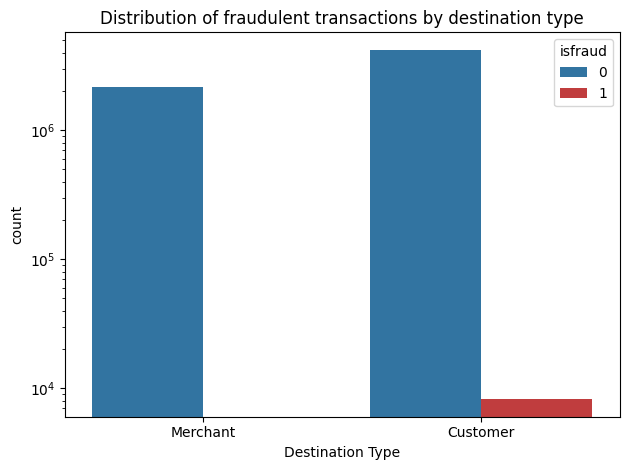

In [170]:
sns.countplot(data=df, x='dest_type', hue='isfraud', palette=['#1f77b4', '#d62728'])
plt.title('Distribution of fraudulent transactions by destination type')
plt.yscale('log')  # Log scale to better visualize the distribution
plt.xlabel('Destination Type')
plt.tight_layout()
plt.show()

"All fraudulent transactions were directed exclusively to customer destination accounts, with no fraud recorded against merchant destinations. This aligns with the dataset documentation, which states that balance information for merchant accounts is unavailable. As a result, the destination account type serves as a strong binary feature — transactions directed toward merchant accounts carry zero fraud risk by design in this dataset."

In [171]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,day,day_name,hour_of_day,dest_type
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,1,Monday,1,Merchant
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0,1,Monday,1,Merchant
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,1,Monday,1,Customer
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,1,Monday,1,Customer
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,1,Monday,1,Merchant


**Feature Engineering**

In [172]:
df.head()
df.groupby('type')['isfraud'].mean().reset_index(name='fraud_rate').sort_values(by='fraud_rate',ascending=False)

/tmp/ipykernel_57/2526500494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('type')['isfraud'].mean().reset_index(name='fraud_rate').sort_values(by='fraud_rate',ascending=False)


,type,fraud_rate
4,TRANSFER,0.007688
1,CASH_OUT,0.001840
0,CASH_IN,0.000000
2,DEBIT,0.000000
3,PAYMENT,0.000000


**From the above analysis, we can observe that the 'transfer' and 'cash_out' transaction types have significantly higher fraud rates compared to other transaction types. This insight can be crucial for building a fraud detection model, as it indicates that these transaction types are more likely to be associated with fraudulent activities. Therefore, we should consider giving more weight to these features in our model or even creating additional features based on these transaction types to improve the model's performance in detecting fraud.**

Transaction Type features

In [174]:
df['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)  #creating a new feature is_transfer which indicates whether the transaction type is a transfer or not
df['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)  #creating a new feature is_cash_out which indicates whether the transaction type is a cash out or not   
df['is_merchant_dest'] = (df['dest_type'] == 'Merchant').astype(int)  #creating a new feature is_merchant_dest which indicates whether the destination account is a merchant or not based on the dest_type column   


Amount features


In [175]:
df['log_amount'] = np.log1p(df['amount'])  #creating a new feature log_amount which is the logarithm of the transaction amount to reduce the skewness of the distribution
df['critical_transaction'] = (df['amount'] > 200000).astype(int)  #creating a new feature critical_amount which indicates whether the transaction amount is greater than 200000 or not, and this is totally based on the context of the dataset
df['is_round'] = (df['amount'] % 1000 == 0).astype(int)  #creating a new feature is_round which indicates whether the transaction amount is a round number (multiple of 1000) or not, as fraudsters often use round numbers to avoid detection
#and this 200000 threshold is chosen based on the context of the dataset.

#we must sort the df before measuring the frequency of transaction
df=df.sort_values('step').reset_index(drop=True)  #sorting the dataframe based on time step
#here we are measuring the frequency of transaction done by each account user till current time


Time features

From the context of dataset, we must drop features such as oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest and any features made up of using those features, cause those features are not available at the time of transaction and they are only updated after the transaction is completed, so we cannot use those features for real-time fraud detection as they will not be available at the time of prediction.
So we must drop them before training the model

In [176]:
df['day_of_week'] = (df['day'] - 1) % 7  # 0=Monday, 1=Tuesday, ... 6=Sunday  
df['is_night_transaction'] = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] <= 6)).astype(int)  #creating a new feature is_night_transaction which indicates whether the transaction occurred during the night hours (0-6) or not, as fraudulent transactions may be more likely to occur during these hours    


In [177]:
df.head()

,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isfraud,isflaggedfraud,day,day_name,hour_of_day,dest_type,is_transfer,is_cash_out,is_merchant_dest,log_amount,critical_transaction,is_round,day_of_week,is_night_transaction
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0,1,Monday,1,Merchant,0,0,1,9.194276,0,0,0,1
1,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0,1,Monday,1,Customer,1,0,0,5.204007,0,0,0,1
2,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0,1,Monday,1,Customer,0,1,0,5.204007,0,0,0,1
3,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0,1,Monday,1,Merchant,0,0,1,9.364703,0,0,0,1
4,1,PAYMENT,7817.709961,C90045638,53860.0,46042.289062,M573487274,0.0,0.0,0,0,1,Monday,1,Merchant,0,0,1,8.964274,0,0,0,1


Dropping unnecessary features

In [178]:
drop_cols = ['type', 'namedest', 'isflaggedfraud',
        'oldbalanceorg', 'newbalanceorig', 'oldbalancedest', 'newbalancedest', 'hour_of_day', 'day','dest_type','day_name']
df= df.drop(columns=drop_cols)

**Model Training**

splitting the dataset into train and test sets

In [179]:
df1=df.sort_values('step').reset_index(drop=True)  #sorting the dataframe based on time step
X=df1.drop(columns = ['isfraud'])
y=df1['isfraud']


#for steps to split dataset into training, cross_Validation and test dataset
train_step= 575    # day 1to 15, for the training dataset
val_step=647      # day 16 to 23, fot the cross_validation dataset

train_mask=df1['step']<=train_step  #training dataset
val_mask=(df1['step']>train_step)&((df1['step']<=val_step))  #cross_validation dataset
test_mask=df1['step']>val_step   #test dataset

#splitting of dataset
X_train,X_val, X_test=X[train_mask].copy(),X[val_mask].copy(), X[test_mask].copy()
y_train,y_val, y_test=y[train_mask].copy(),y[val_mask].copy(), y[test_mask].copy() 
#inorder to prevent the dataleakage, we are using the transaction mean based on training dataset only
train_account_mean = X_train.groupby('nameorig')['amount'].mean() #finding the mean of all the transaction amounts based on the account holder name
X_train['amount_vs_account_mean'] = X_train['amount'] / (X_train['nameorig'].map(train_account_mean)+ 1 ) #checking how much the current transaction amount is different from the usual transaction amount of the user, can be effective feature for fraud detection
global_mean = X_train['amount'].mean() #here we are calculating the global mean for the backup of filling the null values of transaction mean for the validation and test dataset

#here global mean is the fallback value, if the nameorig in validation or test dataset isnot found in training dataset
X_test['amount_vs_account_mean'] = X_test['amount'] / (X_test['nameorig'].map(train_account_mean).fillna(global_mean)+ 1) 
X_val['amount_vs_account_mean'] = X_val['amount'] / (X_val['nameorig'].map(train_account_mean).fillna(global_mean) + 1)

train_transaction_counts = X_train.groupby('nameorig')['amount'].count()  #here we are calculating the transaction count for each account holder in the training dataset
X_train['account_txn_counts'] = X_train['nameorig'].map(train_transaction_counts).fillna(0) + 1  #here we are creating a new feature called transaction count per account which indicates how many transactions have been made by the account holder, based on the training dataset
X_val['account_txn_counts'] = X_val['nameorig'].map(train_transaction_counts).fillna(0)+1  #here we are calculating the transaction count for each account holder in the validation dataset based on the training dataset,
X_test['account_txn_counts'] = X_test['nameorig'].map(train_transaction_counts).fillna(0)+1 #same here for test dataset

X_train = X_train.drop(columns = ['amount','nameorig'])
X_val = X_val.drop(columns = ['amount','nameorig'])
X_test = X_test.drop(columns = ['amount','nameorig'])

Preprocessing pipeline

In [180]:
#scaling pipeline
scalar = RobustScaler()
continuous_features = ['log_amount','amount_vs_account_mean','account_txn_counts', 'step']

X_train[continuous_features] = scalar.fit_transform(X_train[continuous_features])
X_val[continuous_features] = scalar.transform(X_val[continuous_features])
X_test[continuous_features] = scalar.transform(X_test[continuous_features])

Downsampling on training dataset

In [181]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='majority')  #here we are reducing the number of majority classes
X_train_down, y_train_down = rus.fit_resample(X_train, y_train)

In [182]:
import joblib


with open('preprocessors.pkl', 'wb') as f:
    joblib.dump({'scalar':scalar,
                'train_account_mean':train_account_mean,
                'global_mean':global_mean,
                'account_txn_counts':train_transaction_counts


            }, f)

print("Saved to the VM✓")

Saved to the VM✓


Since the dataset is highly imbalanced, we will be using the class_weight parameter in our models to give more weight to the minority class (fraudulent transactions) during training. This helps the model to learn better from the minority class and improve its performance in detecting fraudulent transactions. And we will evaluate the model with balanced class weight and without balanced class weight, but with SMOTE oversampling technique to handle the class imbalance. And choose the one with best PR-AUC, Recall, ROC-AUC

In [183]:
model1 = LGBMClassifier(verbose=-1, n_estimators=100, random_state=42,n_jobs=-1)
model1.fit(X_train_down, y_train_down)
y_prob_down=model1.predict_proba(X_val)[:,1]  #here we are extracting the probability of true positive class
#here we are predicting the probabilities of the positive class (fraud) for the test set, which can be used for further evaluation metrics like ROC-AUC or precision-recall curves.
y_pred_down=model1.predict(X_val)

Using SMOTE to balance the dataset to increase the number of minority class (fraud) 

In [184]:
smote = SMOTE(random_state=42)  #here we are using SMOTE to handle the class imbalance in the dataset by generating synthetic samples for the minority class (fraud) based on the existing samples in the training set, which can help improve the performance of the model in detecting fraudulent transactions.
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)  #here we are applying SMOTE to the training data to create a new balanced training set with synthetic samples for the minority class (fraud), which can help improve the model's ability to learn from the data and detect fraudulent transactions more effectively.
model2 = LGBMClassifier(verbose=-1, n_estimators=100, random_state=42)
model2.fit(X_train_smote, y_train_smote)
y_pred_smote = model2.predict(X_val)  #predicting the class labels for test dataset
y_prob_smote = model2.predict_proba(X_val)[:, 1]  #here we are predicting the probabilities of the positive class (fraud) for the test set, which can be used for further evaluation metrics like ROC-AUC or precision-recall curves.

In [185]:
model3 = LGBMClassifier(verbose=-1,class_weight='balanced' ,n_estimators=100, random_state=42)
model3.fit(X_train, y_train)
y_pred_balanced = model3.predict(X_val)  #predicting the class labels for test dataset
y_prob_balanced = model3.predict_proba(X_val)[:, 1]


In [186]:
#here we are comparing the evaluation metrics of the two models, one trained with down sampling method and the other trained with SMOTE, to see which approach performs better in terms of handling class imbalance in fraud detection. We are calculating metrics such as ROC-AUC, PR-AUC, Recall, and Precision for both models and presenting them in a tabular format for easy comparison.
comparison = {
    'down_sample': {
        'ROC-AUC'  : round(roc_auc_score(y_val, y_prob_down), 4),
        'PR-AUC'   : round(average_precision_score(y_val, y_prob_down), 4),
        'Recall'   : round(recall_score(y_val, y_pred_down), 4),
        'Precision': round(precision_score(y_val, y_pred_down), 4),
    },
    'SMOTE': {
        'ROC-AUC'  : round(roc_auc_score(y_val, y_prob_smote), 4),
        'PR-AUC'   : round(average_precision_score(y_val, y_prob_smote), 4),
        'Recall'   : round(recall_score(y_val, y_pred_smote), 4),
        'Precision': round(precision_score(y_val, y_pred_smote), 4),
    },
    'class_weight': {
        'ROC-AUC'  : round(roc_auc_score(y_val, y_prob_balanced), 4),
        'PR-AUC'   : round(average_precision_score(y_val, y_prob_balanced), 4),
        'Recall'   : round(recall_score(y_val, y_pred_balanced), 4),
        'Precision': round(precision_score(y_val, y_pred_balanced), 4),
    }
}
print(pd.DataFrame(comparison).T)

              ROC-AUC  PR-AUC  Recall  Precision
down_sample    0.9226  0.3476  1.0000     0.0229
SMOTE          0.8612  0.2351  0.7273     0.0415
class_weight   0.9294  0.3811  0.9684     0.0258


From the above dataframe we can see that the model trained with balanced class weight method has a higher ROC-AUC and PR-AUC compared to the model trained with downsampling and SMOTE method, indicating that it performs better in distinguishing between fraudulent and non-fraudulent transactions. Additionally, the trained model with balanced class weight has a higher precision, which means it is better at correctly identifying fraudulent transactions while minimizing false positives.

Multi-model comparison

In [187]:
import cupy as cp
X_train_gpu = cp.array(X_train)
X_val_gpu = cp.array(X_val)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

In [188]:
models = {
'LightGBM': LGBMClassifier(verbose=-1, class_weight='balanced',
                                n_estimators=100, random_state=42),
'XGBoost': XGBClassifier(scale_pos_weight=neg/pos,    #here we are using scale_pos_weight to increase the importance of positive class 
                              n_estimators=100, random_state=42,device='cuda',tree_method='hist'),
'Random Forest': XGBRFClassifier(scale_pos_weight=neg/pos, n_estimators=100,
                                            random_state=42, device='cuda',                
                    tree_method='hist',
                    subsample=0.9,                #  high subsample for time series
                    colsample_bynode=0.8 ),

}

In [189]:

result = {}
for name,model in models.items():
    if name =='LightGBM':
         model = model.fit(X_train,y_train)
         y_prob = model.predict_proba(X_val)[:, 1] #only extracting the probability of the positive class (fraud)
         y_pred = model.predict(X_val)  
    else:
        model = model.fit(X_train_gpu,y_train)
        y_prob = model.predict_proba(X_val_gpu)[:, 1]  #only extracting the probability of the positive class (fraud)
        y_pred = model.predict(X_val_gpu)    
    
    result[name] = {
        'F1': round(f1_score(y_val, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_val, y_prob), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4)
    }
df = pd.DataFrame(result).T

In [190]:
df

,F1,ROC-AUC,PR-AUC,Recall,Precision
LightGBM,0.0503,0.9294,0.3811,0.9684,0.0258
XGBoost,0.0562,0.9029,0.3337,0.9053,0.0290
Random Forest,0.0439,0.8905,0.3435,0.9533,0.0225


From the above report we can see that LightGBM model has higher PR-AUC and Recall, where as Random Forest has higher F1 score and Precision, which is 1, and is suspicious.So we must proceed to find the optimal threshold for each models, inorder to find the best model.

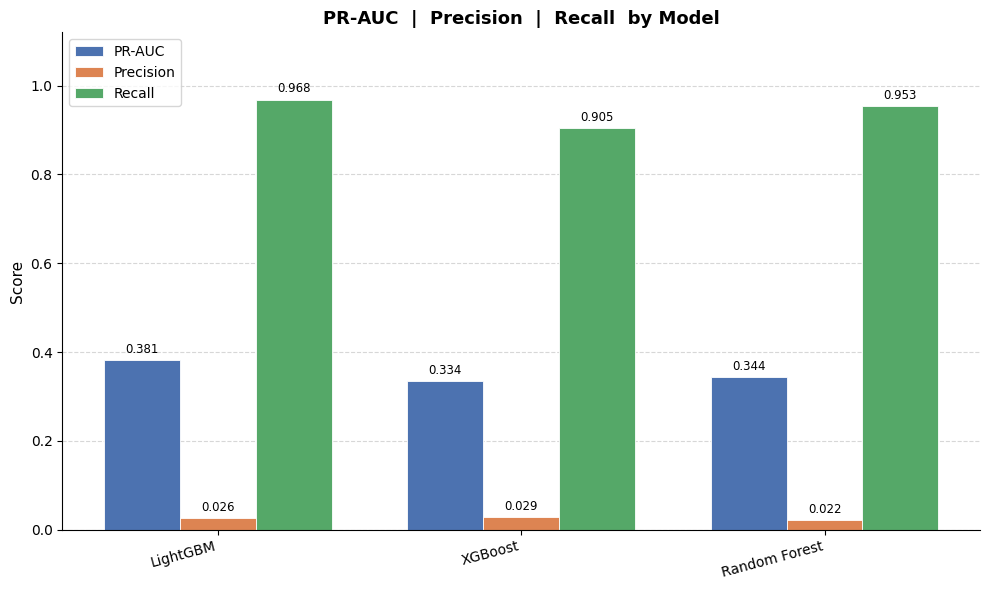

In [191]:
metrics   = ['PR-AUC', 'Precision', 'Recall']
colors    = ['#4C72B0', '#DD8452', '#55A868']   # blue, orange, green
n_models  = len(df)
n_metrics = len(metrics)

x     = np.arange(n_models)
width = 0.25                                    # bar width

fig, ax = plt.subplots(figsize=(10, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(
        x + i * width,
        df[metric],
        width,
        label=metric,
        color=color,
        edgecolor='white',
        linewidth=0.6
    )
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8.5)
ax.set_xticks(x + width)                        # center ticks
ax.set_xticklabels(df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('PR-AUC  |  Precision  |  Recall  by Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.12)                            # headroom for labels
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

class for early stopping for optuna trials

In [192]:
class EarlyStoppingCallback:
    def __init__(self, patience):
        self.patience = patience
        self.best_value = None
        self.stagnant_trials = 0

    def __call__(self, study, trial):
        try:
            current_best = study.best_value
        except ValueError:
            return 

        if self.best_value is None or current_best > self.best_value:
            self.best_value = current_best
            self.stagnant_trials = 0
        else:
            self.stagnant_trials += 1
        if self.stagnant_trials >= self.patience:
            print(f"Stopping study: No improvement for {self.patience} trials.")
            study.stop()

Experimentation of different models and hyperparameter tuning

In [193]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
from lightgbm import early_stopping

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42  

def optimize_model_cv(X_train, X_val, X_test, y_train, y_val, y_test, models, n_trials=25):
    cv = TimeSeriesSplit(n_splits=5)
    hyperparameter_tuned_models = {}
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    for model_name in models:
        def objective(trial, model_name=model_name):  
            fold_scores = []

            for fold, (train_idx, val_idx) in enumerate(cv.split(X_train)):
                X_tr = X_train.iloc[train_idx]
                X_fold_val = X_train.iloc[val_idx]
                y_tr = y_train.iloc[train_idx]
                y_fold_val = y_train.iloc[val_idx]

                if model_name == 'Random Forest':
                    params = {
                            "n_estimators": trial.suggest_int("n_estimators", 50, 150),
                            "max_depth": trial.suggest_int("max_depth", 3, 7),
                            "subsample": trial.suggest_float("subsample", 0.7, 1.0),        #  keeping high for time series
                            "colsample_bynode": trial.suggest_float("colsample_bynode", 0.3, 1.0),  #  like max_features
                            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                            # fixed params
                            "scale_pos_weight": scale_pos_weight,
                            "random_state": SEED,
                            "device": "cuda",
                            "tree_method": "hist",
                    }
                    model = XGBRFClassifier(**params)
                    model.fit(X_tr, y_tr)

                elif model_name == 'XGBoost':
                    # Conditional CUDA
                    try:
                        import subprocess
                        subprocess.check_output('nvidia-smi')
                        device = 'cuda'
                    except Exception:
                        device = 'cpu'

                    params = {
                        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
                            "max_depth": trial.suggest_int("max_depth", 3, 10),
                            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                            # fixed params
                            "scale_pos_weight": scale_pos_weight,
                            "random_state": SEED,
                            "eval_metric": "aucpr",
                            "device": "cuda",
                            "tree_method": "hist",
                            "early_stopping_rounds": 15,
                    }
                    model = XGBClassifier(**params)
                    model.fit(X_tr, y_tr, eval_set=[(X_fold_val, y_fold_val)], verbose=False)

                elif model_name == 'LightGBM':
                    params = {
                        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
                            "max_depth": trial.suggest_int("max_depth", 3, 7),
                            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                            "min_child_samples": trial.suggest_int("min_child_samples", 2, 20),
                            "num_leaves": trial.suggest_int("num_leaves", 20, 50),
                            # fixed params
                            "scale_pos_weight": scale_pos_weight,
                            "random_state": SEED,
                            "n_jobs":-1,
                    }
                    model = LGBMClassifier(**params)
                    model.fit(X_tr, y_tr, eval_set=[(X_fold_val, y_fold_val)],
                              callbacks=[early_stopping(stopping_rounds=15, verbose=False)])

                y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
                score = average_precision_score(y_fold_val, y_pred_proba)
                fold_scores.append(score)

                trial.report(np.mean(fold_scores), fold)
                if trial.should_prune():
                    raise optuna.TrialPruned()

            return np.mean(fold_scores)

        study = optuna.create_study(
            direction='maximize',
            sampler=TPESampler(seed=SEED),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)  
        )
        study.optimize(objective, n_trials=n_trials, n_jobs=1)

        hyperparameter_tuned_models[model_name] = study.best_params
        print(f"{model_name} | Best PR-AUC: {study.best_value:.4f} | Params: {study.best_params}")

    return X_train, X_val, X_test, y_train, y_val, y_test, hyperparameter_tuned_models
X_train,X_val,X_test,y_train,y_val,y_test,hyperparameter_tuned_models= optimize_model_cv(X_train,X_val,X_test,y_train,y_val,y_test, models,n_trials=25)    

LightGBM | Best PR-AUC: 0.1591 | Params: {'n_estimators': 244, 'max_depth': 4, 'learning_rate': 0.013722987188971322, 'subsample': 0.9578517328158417, 'colsample_bytree': 0.888830662726227, 'min_child_samples': 15, 'num_leaves': 42}
XGBoost | Best PR-AUC: 0.2043 | Params: {'n_estimators': 101, 'max_depth': 5, 'learning_rate': 0.03201828161751499, 'subsample': 0.839814514046141, 'colsample_bytree': 0.6875208029306935, 'min_child_weight': 1}
Random Forest | Best PR-AUC: 0.1801 | Params: {'n_estimators': 111, 'max_depth': 3, 'subsample': 0.7876433945605654, 'colsample_bynode': 0.5564532903055841, 'min_child_weight': 5}


In [194]:
SEED =42
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

fitted_model = {}
thresholds = {}
for name, best_params in hyperparameter_tuned_models.items():
            if name == 'Random Forest':
                model = XGBRFClassifier(**best_params)
            elif name == 'XGBoost': 
                model = XGBClassifier(**best_params)
            else:
                model = LGBMClassifier(**best_params)       
           
            model.fit(X_train, y_train)  #fitting the model on the training data
            y_prob = model.predict_proba(X_val)[:, 1]  #only extracting the probability of the positive class (fraud)
                
            fitted_model[name] = model   
            print(f'saved the trained model {name}')
            
            precisions, recalls, thresh = precision_recall_curve(y_val, y_prob)
            fbeta = (1 + 4) * (precisions * recalls) / (4 * precisions + recalls + 1e-8)
            best_idx = fbeta.argmax()
            thresholds[name] = thresh[best_idx]
            print(f"Best threshold: {thresh[best_idx]:.4f}")


            

       

saved the trained model LightGBM
Best threshold: 0.0650
saved the trained model XGBoost
Best threshold: 0.0546
saved the trained model Random Forest
Best threshold: 0.1001


multimodel comparison with best threshold

In [195]:

result = {}
for name,model in fitted_model.items():
    y_prob = model.predict_proba(X_val)[:, 1]  #only extracting the probability of the positive class (fraud)
    y_pred = (y_prob>=thresholds[name]).astype(int)    #then based on the optimal threshold, we are finding the prediction done by each trained model
    
    result[name] = {
        'F1': round(f1_score(y_val, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_val, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_val, y_prob), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
        'Precision': round(precision_score(y_val, y_pred), 4)
    }

In [196]:
pd.DataFrame(result).T     

,F1,ROC-AUC,PR-AUC,Recall,Precision
LightGBM,0.3904,0.9532,0.4534,0.5253,0.3107
XGBoost,0.3667,0.9410,0.3803,0.5316,0.2799
Random Forest,0.0557,0.8049,0.0245,0.8965,0.0288


**Evaluation done on test dataset**

In [197]:
total_models_result = {}
for name,model in fitted_model.items():
    y_prob = model.predict_proba(X_test)[:, 1]  #only extracting the probability of the positive class (fraud)
    y_pred = (y_prob>=thresholds[name]).astype(int)    #then based on the optimal threshold, we are finding the prediction done by each trained model
    
    total_models_result[name] = {
        'F1': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC': round(average_precision_score(y_test, y_prob), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4)
    }
print(pd.DataFrame(total_models_result).T)    

                   F1  ROC-AUC  PR-AUC  Recall  Precision
LightGBM       0.4060   0.9471  0.4941  0.5311     0.3287
XGBoost        0.5231   0.9462  0.5119  0.5066     0.5407
Random Forest  0.0694   0.7953  0.0309  0.8879     0.0361


**From the above evaluation report of testing model on test dataset with optimal threshold, we can observe that XGBoost is the best model with the eval_metrics.** 

In [206]:
best_model_name='XGBoost'
best_model = fitted_model[best_model_name]  #trained model, which was trained on training dataset, and evaluated on both cross_validation and test dataset
best_threshold = thresholds[best_model_name]


Here, we are saving the model info, with model_name, model, threshold and metrics. Model and threshold will be used to predict whether the incoming data of transaction is fraud or legit.

In [207]:
best_model_info = {
            'model': best_model,
            'threshold': best_threshold,
            'model_name': best_model_name,
            'metrics': total_models_result[best_model_name]}
with open('best_model_info.pkl', 'wb') as f:
    joblib.dump(best_model_info, f)
    

print("Saved to kaggle ✓")
print(f"\nSaved {best_model_info} → best_model_info.pkl ✓")

Saved to kaggle ✓

Saved {'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6875208029306935, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03201828161751499,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=101, n_jobs=None,
              num_parallel_tree=None, ...), 'threshold': np.float32(0.054622345), 'model_name': 'XGBoost', 'metrics': {'F1': 0.5231, 'ROC-AUC': np.float64(0.9462), 'PR-AUC': np.float64(0.5119), 'Recall': 0.5066,